# SleepPy Extraction Review

This notebook reviews first-pass sleep metric extraction from Oura Ring 4 finger, Oura Ring 3 toe, Samsung Watch / SleepWatch, Muse screenshots/PDFs, MindMonitor/Muse sensor-log CSVs, and OSCAR/SleepScope sample screenshots or PDFs.

**Disclaimer:** This is exploratory wellness data analysis only. It is not medical diagnosis, treatment advice, or a replacement for clinician review.


## Workflow

1. Place 1-2 representative files per device under `data/raw/samples/<device>/`.
2. Run the extraction cell to create `data/processed/nightly_summary.csv`, `data/processed/device_observations_long.csv`, and `outputs/extraction_report.md`.
3. Review extracted values, missingness, confidence labels, and trend plots.
4. Correct low-confidence or missing values manually before treating them as analysis inputs.

**After adding or moving raw files, rerun extraction in this notebook by setting `RUN_EXTRACTION = True`, or run `python -m sleeppy.extract --no-legacy-raw` before loading existing processed CSVs. Loading existing CSVs will not discover newly added dated subfolders.**



In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import pandas as pd

# Reload local modules so an already-running notebook kernel picks up edits from disk.
import sleeppy.schema as sleep_schema
import sleeppy.quality as sleep_quality
import sleeppy.extract as sleep_extract
import sleeppy.extract.common as extract_common
import sleeppy.extract.pipeline as extract_pipeline

importlib.reload(sleep_schema)
importlib.reload(sleep_quality)
importlib.reload(extract_common)
importlib.reload(extract_pipeline)
importlib.reload(sleep_extract)

check_ocr_environment = extract_common.check_ocr_environment
run_sample_extraction = extract_pipeline.run_sample_extraction
confidence_by_device = sleep_quality.confidence_by_device
describe_extraction_outputs = sleep_quality.describe_extraction_outputs
missingness_by_device = sleep_quality.missingness_by_device
observations_to_nightly_summary = sleep_quality.observations_to_nightly_summary
CANONICAL_METRIC_UNITS = sleep_schema.CANONICAL_METRIC_UNITS
OPTIONAL_PLOT_METRICS = sleep_schema.OPTIONAL_PLOT_METRICS
PLOT_METRICS = sleep_schema.PLOT_METRICS
ensure_observations_frame = sleep_schema.ensure_observations_frame
normalize_summary_columns = sleep_schema.normalize_summary_columns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

MINDMONITOR_DEVICE = "Muse S MindMonitor"
MINDMONITOR_COVERAGE_METRICS = [
    "mindmonitor_session_start_time",
    "mindmonitor_session_end_time",
    "mindmonitor_session_minutes",
    "mindmonitor_valid_eeg_rows",
    "mindmonitor_valid_motion_rows",
    "mindmonitor_valid_ppg_rows",
    "mindmonitor_mean_hr_bpm",
    "mindmonitor_mean_accel_mag",
    "mindmonitor_p95_accel_mag",
    "mindmonitor_stopped_before_morning",
    "mindmonitor_gap_count_gt_5s",
    "mindmonitor_max_gap_seconds",
]


## OCR Diagnostics

The notebook must have dependencies installed in the active kernel shown below. If `image_ocr_ready` is `False`, run `import sys; !"{sys.executable}" -m pip install -r requirements.txt`, then restart the kernel.

In [2]:
ocr_status = check_ocr_environment()
display(pd.DataFrame([ocr_status]))

if not ocr_status["image_ocr_ready"]:
    print("Image OCR is not ready in this active notebook kernel. Screenshots will produce zero extracted values until this is fixed.")
    print(ocr_status["notes"])
else:
    print("Image OCR is ready.")

,python_executable,pillow_installed,pytesseract_installed,pymupdf_installed,tesseract_cmd,tesseract_version,image_ocr_ready,pdf_text_ready,notes
0,C:\Users\morri\miniconda3\python.exe,True,True,True,C:\Program Files\Tesseract-OCR\tesseract.exe,5.4.0.20240606,True,True,OCR/PDF dependencies look ready.


Image OCR is ready.


In [3]:
# Set to True to rerun OCR extraction
RUN_EXTRACTION = False
# Set to True to re-pivot summary from observations
REBUILD_SUMMARY_FROM_OBSERVATIONS = False

nightly_summary_exists = (PROCESSED_DIR / "nightly_summary.csv").exists()

if RUN_EXTRACTION:
    nightly_summary, observations, report_path = run_sample_extraction(
        raw_samples_dir=PROJECT_ROOT / "data" / "raw" / "samples",
        processed_dir=PROCESSED_DIR,
        outputs_dir=OUTPUTS_DIR,
        include_legacy_raw=True,
    )
else:
    print("Loading existing processed data.")
    print("Reminder: set RUN_EXTRACTION=True after adding raw files or dated subfolders.")
    nightly_summary = pd.read_csv(PROCESSED_DIR / "nightly_summary.csv")
    observations = pd.read_csv(PROCESSED_DIR / "device_observations_long.csv")
    report_path = OUTPUTS_DIR / "extraction_report.md"

observations = ensure_observations_frame(observations)

if REBUILD_SUMMARY_FROM_OBSERVATIONS or not nightly_summary_exists:
    if observations.empty:
        nightly_summary = normalize_summary_columns(nightly_summary)
    else:
        nightly_summary = observations_to_nightly_summary(observations)
else:
    nightly_summary = normalize_summary_columns(nightly_summary)

print(f"Night/device rows: {len(nightly_summary)}")
print(f"Extracted values: {len(observations)}")
print(f"Report: {report_path}")
print("Available devices:", sorted(observations["device"].dropna().unique().tolist()))
print("Available observation metrics:", sorted(observations["metric"].dropna().unique().tolist()))
print("Nightly summary columns:", list(nightly_summary.columns))

extraction_diagnostics = describe_extraction_outputs(nightly_summary, observations)


Loading existing processed data.
Reminder: set RUN_EXTRACTION=True after adding raw files or dated subfolders.
Night/device rows: 42
Extracted values: 420
Report: C:\Users\morri\PycharmProjects\SleepPy\outputs\extraction_report.md
Available devices: ['Muse S MindMonitor', 'Oura Ring 3 toe', 'Oura Ring 4 finger', 'ResMed AirSense 11', 'Samsung Watch', 'Samsung Watch / SleepWatch']
Available observation metrics: ['avg_hr_bpm', 'avg_hrv_ms', 'avg_spo2_pct', 'awake_minutes', 'breathing_label', 'cpap_ahi', 'cpap_leak_rate', 'cpap_usage_hours', 'deep_minutes', 'light_minutes', 'min_hr_bpm', 'mindmonitor_battery_max', 'mindmonitor_battery_min', 'mindmonitor_expected_sleep_window_coverage_pct', 'mindmonitor_gap_count_gt_5s', 'mindmonitor_headband_on_fraction', 'mindmonitor_max_gap_seconds', 'mindmonitor_mean_accel_mag', 'mindmonitor_mean_alpha', 'mindmonitor_mean_beta', 'mindmonitor_mean_delta', 'mindmonitor_mean_gamma', 'mindmonitor_mean_gyro_mag', 'mindmonitor_mean_hr_bpm', 'mindmonitor_mean

## Extracted Tables

In [4]:
display(nightly_summary)
display(observations.head(50))

,night_date,device,total_sleep_minutes,time_in_bed_minutes,sleep_efficiency_pct,sleep_score,avg_hr_bpm,min_hr_bpm,avg_hrv_ms,avg_spo2_pct,min_spo2_pct,respiratory_rate_bpm,temperature_deviation_c,readiness_score,cpap_ahi,cpap_usage_hours,cpap_leak_rate,cpap_pressure,awake_minutes,rem_minutes,light_minutes,deep_minutes,max_hrv_ms,hrv_balance_score,breathing_label,cpap_cai,cpap_oai,source_files,extraction_methods,min_confidence,notes
0,2026-05-09,Muse S MindMonitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\samples\mind_monitor\2026-05-09\museM...,csv; derived,medium,Derived from MindMonitor session_minutes divid...
1,2026-05-09,Oura Ring 3 toe,314.0,383.0,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.0,27.0,251.0,35.0,NaN,NaN,NaN,NaN,NaN,data\raw\samples\oura3\IMG_0835_20260509.PNG; ...,cache,high,cached; time_in_bed_minutes corrected from tot...
2,2026-05-09,Oura Ring 4 finger,321.0,369.0,87.0,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,NaN,259.0,27.0,NaN,NaN,NaN,NaN,NaN,data\raw\samples\oura4\IMG_1077_20260509.PNG; ...,cache,high,cached; time_in_bed_minutes corrected from tot...
3,2026-05-09,Samsung Watch / SleepWatch,319.0,360.0,NaN,NaN,NaN,NaN,NaN,94.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.0,87.0,161.0,71.0,NaN,NaN,NaN,NaN,NaN,data\raw\samples\samsung_watch\Screenshot 2026...,cache,high,cached; cached; Samsung stage block: Awake 11%...
4,2026-06-08,Samsung Watch / SleepWatch,NaN,NaN,NaN,NaN,57.0,NaN,NaN,94.0,NaN,11.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\samples\samsung_watch\Screenshot_2026...,cache,high,cached
5,2026-06-17,Oura Ring 3 toe,432.0,485.0,89.0,NaN,NaN,71.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.0,76.0,261.0,95.0,NaN,NaN,NaN,NaN,NaN,data\raw\samples\oura3\Sleep toe 6-17-26 at 6....,cache,high,cached; time_in_bed_minutes corrected from tot...
6,2026-06-17,Samsung Watch / SleepWatch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,99.0,197.0,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\samples\samsung_watch\Sleep watch 6-1...,cache,high,cached
7,2026-06-19,Oura Ring 3 toe,616.0,821.0,75.0,87.0,NaN,39.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,195.0,107.0,460.0,59.0,NaN,NaN,NaN,NaN,NaN,data\raw\samples\oura3\Oura toe 6-19-26 2.pdf,cache,high,cached
8,2026-06-19,Samsung Watch / SleepWatch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\samples\samsung_watch\sleep watch 6-1...,cache,high,cached
9,2026-06-20,Oura Ring 3 toe,322.0,NaN,NaN,NaN,NaN,56.0,NaN,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,NaN,NaN,NaN,NaN,NaN,data\raw\samples\oura3\Sleep Oura 3 toe 6-20-2...,cache,high,cached


,night_date,device,metric,value,unit,source_file,extraction_method,confidence,notes
0,<NA>,Oura Ring 4 finger,awake_minutes,48,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
1,<NA>,Oura Ring 4 finger,rem_minutes,73,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
2,<NA>,Oura Ring 4 finger,light_minutes,265,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
3,<NA>,Oura Ring 4 finger,deep_minutes,43,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
4,<NA>,Oura Ring 4 finger,time_in_bed_minutes,429,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
5,<NA>,Oura Ring 4 finger,total_sleep_minutes,381,minutes,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
6,<NA>,Oura Ring 4 finger,sleep_efficiency_pct,89,pct,data\raw\samples\oura4\0EB30769-382F-4A4B-A4AA...,cache,high,cached
7,2026-07-09,Oura Ring 4 finger,total_sleep_minutes,399,minutes,data\raw\samples\oura4\2026-07-09\IMG_1084.PNG,cache,high,cached
8,2026-07-09,Oura Ring 4 finger,sleep_efficiency_pct,87,pct,data\raw\samples\oura4\2026-07-09\IMG_1084.PNG,cache,high,cached
9,2026-07-09,Oura Ring 4 finger,time_in_bed_minutes,459,minutes,data\raw\samples\oura4\2026-07-09\IMG_1084.PNG,cache,high,cached


## Missingness and Confidence

In [5]:
missingness = missingness_by_device(nightly_summary)
confidence = confidence_by_device(observations)

device_counts = (
    observations.groupby("device")
    .size()
    .rename("observation_count")
    .reset_index()
    .sort_values("device")
)
metric_availability = observations.pivot_table(
    index="metric",
    columns="device",
    values="value",
    aggfunc="count",
    fill_value=0,
)

if missingness.empty:
    print("No nightly summary rows available yet.")
else:
    display(missingness.pivot_table(index="metric", columns="device", values="missing_pct"))

if device_counts.empty:
    print("No extracted observations available yet.")
else:
    display(device_counts)

if metric_availability.empty:
    print("No metric availability table available yet.")
else:
    display(metric_availability)

if confidence.empty:
    print("No confidence counts available yet.")
else:
    display(confidence.pivot_table(index="device", columns="confidence", values="count", fill_value=0))


device,Muse S MindMonitor,Oura Ring 3 toe,Oura Ring 4 finger,ResMed AirSense 11,Samsung Watch,Samsung Watch / SleepWatch
metric,,,,,,
avg_hr_bpm,100.0,100.00,100.000000,100.000000,100.0,64.285714
avg_hrv_ms,100.0,56.25,16.666667,100.000000,0.0,100.000000
avg_spo2_pct,100.0,81.25,83.333333,100.000000,100.0,21.428571
awake_minutes,100.0,37.50,0.000000,100.000000,100.0,28.571429
breathing_label,100.0,93.75,100.000000,100.000000,100.0,100.000000
cpap_ahi,100.0,100.00,100.000000,0.000000,100.0,100.000000
cpap_cai,100.0,100.00,100.000000,100.000000,100.0,100.000000
cpap_leak_rate,100.0,100.00,100.000000,66.666667,100.0,100.000000
cpap_oai,100.0,100.00,100.000000,100.000000,100.0,100.000000


,device,observation_count
0,Muse S MindMonitor,58
1,Oura Ring 3 toe,134
2,Oura Ring 4 finger,133
3,ResMed AirSense 11,6
4,Samsung Watch,1
5,Samsung Watch / SleepWatch,88


device,Muse S MindMonitor,Oura Ring 3 toe,Oura Ring 4 finger,ResMed AirSense 11,Samsung Watch,Samsung Watch / SleepWatch
metric,,,,,,
avg_hr_bpm,0,0,0,0,0,8
avg_hrv_ms,0,8,8,0,1,0
avg_spo2_pct,0,3,3,0,0,14
awake_minutes,0,17,21,0,0,13
breathing_label,0,1,0,0,0,0
cpap_ahi,0,0,0,3,0,0
cpap_leak_rate,0,0,0,1,0,0
cpap_usage_hours,0,0,0,2,0,0
deep_minutes,0,16,15,0,0,8


confidence,high,manual,medium
device,,,
Muse S MindMonitor,0.0,0.0,58.0
Oura Ring 3 toe,134.0,0.0,0.0
Oura Ring 4 finger,130.0,3.0,0.0
ResMed AirSense 11,6.0,0.0,0.0
Samsung Watch,0.0,0.0,1.0
Samsung Watch / SleepWatch,87.0,1.0,0.0


## MindMonitor sensor-log coverage


In [6]:
mindmonitor_observations = observations[observations["device"].eq(MINDMONITOR_DEVICE)].copy()

if mindmonitor_observations.empty:
    print("No MindMonitor sensor-log observations available.")
else:
    mindmonitor_coverage = mindmonitor_observations[
        mindmonitor_observations["metric"].isin(MINDMONITOR_COVERAGE_METRICS)
    ].copy()
    mindmonitor_coverage["value"] = pd.to_numeric(mindmonitor_coverage["value"], errors="coerce")
    mindmonitor_coverage = mindmonitor_coverage.pivot_table(
        index=["night_date", "source_file"],
        columns="metric",
        values="value",
        aggfunc="first",
    ).reset_index()
    mindmonitor_coverage = mindmonitor_coverage.rename(
        columns={metric: metric.removeprefix("mindmonitor_") for metric in MINDMONITOR_COVERAGE_METRICS}
    )
    display(mindmonitor_coverage)


metric,night_date,source_file,gap_count_gt_5s,max_gap_seconds,mean_accel_mag,mean_hr_bpm,p95_accel_mag,session_minutes,stopped_before_morning,valid_eeg_rows,valid_motion_rows,valid_ppg_rows
0,2026-05-09,data\raw\samples\mind_monitor\2026-05-09\museM...,15.0,10.662,0.983,74.314,1.021,388.650,0.0,22955.0,22955.0,22955.0
1,2026-07-09,data\raw\samples\mind_monitor\2026-07-09\museM...,7.0,12.761,0.967,64.911,0.994,150.812,1.0,8883.0,8884.0,8883.0


## Trends

In [7]:
PLOT_SPECS = {
    "total_sleep_minutes": ("Minutes", "Sleep duration"),
    "avg_hrv_ms": ("ms", "Average HRV"),
    "avg_spo2_pct": ("%", "Average SpO2"),
    "cpap_ahi": ("Events/hour", "CPAP AHI"),
}

MINDMONITOR_TREND_SPECS = {
    "mindmonitor_session_minutes": ("Minutes", "MindMonitor session duration"),
    "mindmonitor_mean_hr_bpm": ("bpm", "MindMonitor mean HR"),
    "mindmonitor_mean_accel_mag": ("Magnitude", "MindMonitor mean acceleration magnitude"),
    "mindmonitor_p95_accel_mag": ("Magnitude", "MindMonitor p95 acceleration magnitude"),
}


def available_numeric_metrics(summary_df):
    summary_df = normalize_summary_columns(summary_df)
    metrics = []
    for metric in CANONICAL_METRIC_UNITS:
        if metric in summary_df and pd.to_numeric(summary_df[metric], errors="coerce").notna().any():
            metrics.append(metric)
    return metrics


def plot_metric(summary_df, metric, ylabel, title):
    summary_df = normalize_summary_columns(summary_df)
    if summary_df.empty or metric not in summary_df:
        print(f"No {metric} column available. Available numeric metrics: {available_numeric_metrics(summary_df)}")
        return None

    df = summary_df.copy()
    df["parsed_night_date"] = pd.to_datetime(df["night_date"], errors="coerce")
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    has_metric_values = df[metric].notna().any()
    plottable = df.dropna(subset=["parsed_night_date", metric])
    if plottable.empty:
        if has_metric_values:
            print(f"{metric} values exist, but none have a parseable night_date for trend plotting.")
        else:
            print(f"No plottable {metric} values available. Available numeric metrics: {available_numeric_metrics(summary_df)}")
        return None

    df = plottable
    if df.empty:
        print(f"No plottable {metric} values available. Available numeric metrics: {available_numeric_metrics(summary_df)}")
        return None

    fig, ax = plt.subplots(figsize=(10, 4))
    for device, group in df.groupby("device", sort=True):
        group = group.sort_values("parsed_night_date")
        ax.plot(group["parsed_night_date"], group[metric], marker="o", label=device)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig, ax


def plot_observation_metric(observations_df, metric, ylabel, title, device=None):
    df = observations_df.copy()
    if device is not None:
        df = df[df["device"].eq(device)]
    df = df[df["metric"].eq(metric)]
    if df.empty:
        return None
    df["parsed_night_date"] = pd.to_datetime(df["night_date"], errors="coerce")
    df["numeric_value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["parsed_night_date", "numeric_value"])
    if df.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 4))
    for source_file, group in df.groupby("source_file", sort=True):
        group = group.sort_values("parsed_night_date")
        ax.plot(group["parsed_night_date"], group["numeric_value"], marker="o", label=source_file)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    fig.autofmt_xdate()
    fig.tight_layout()
    return fig, ax


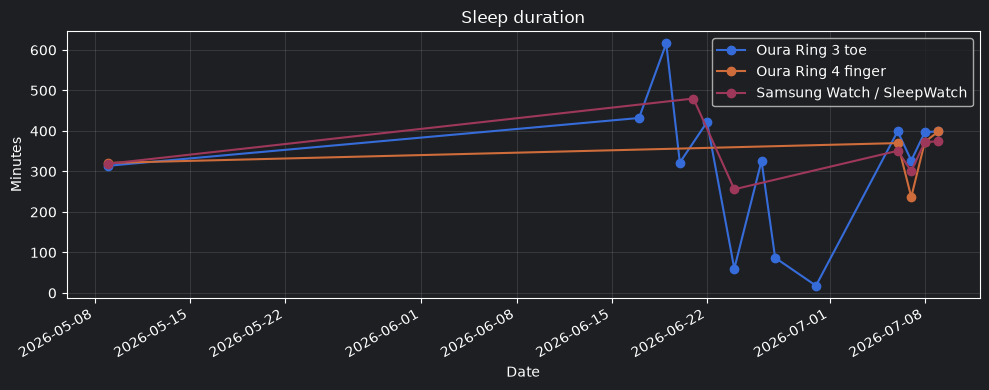

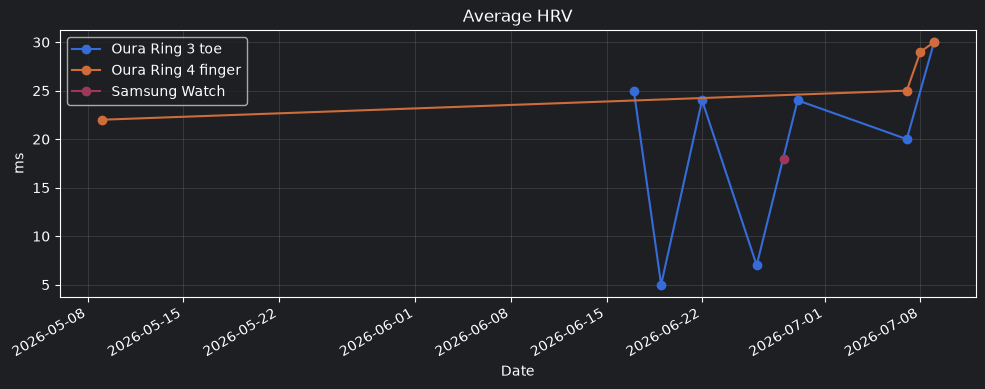

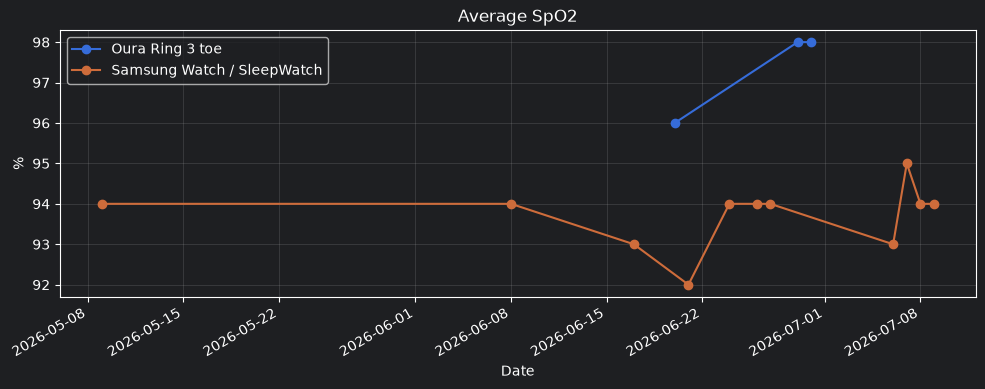

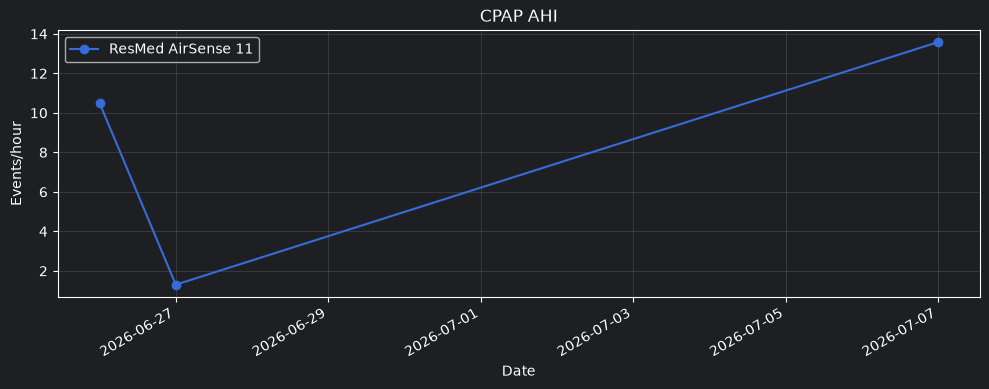

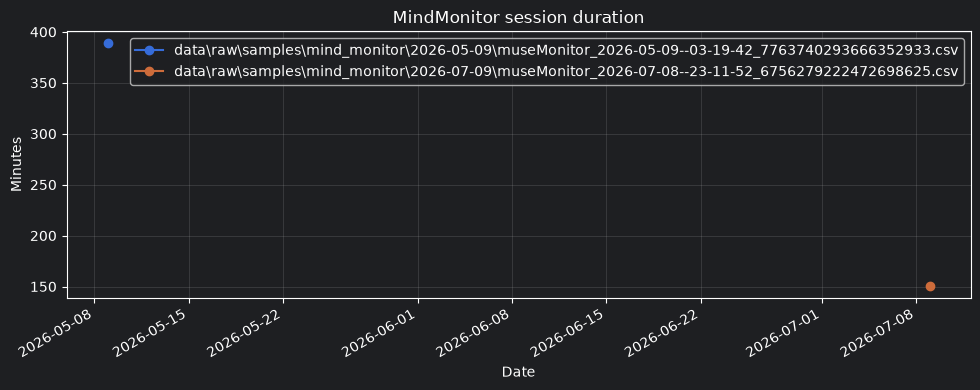

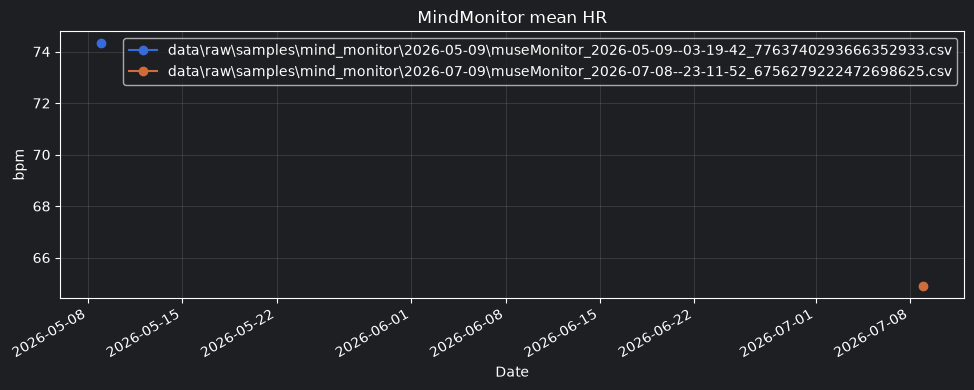

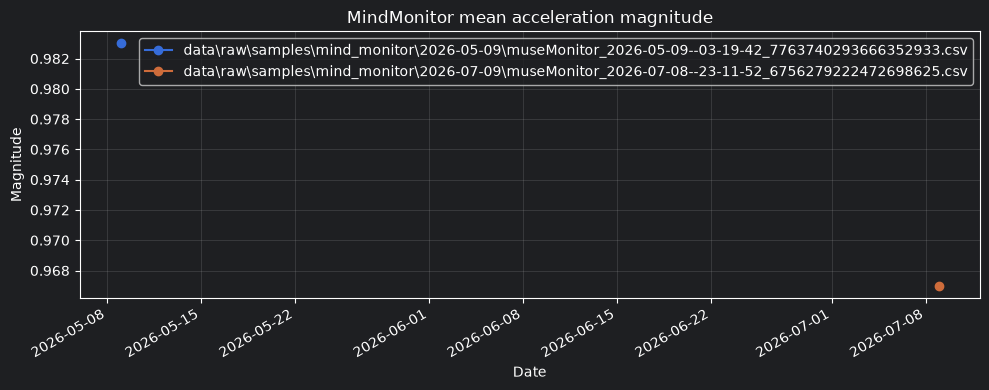

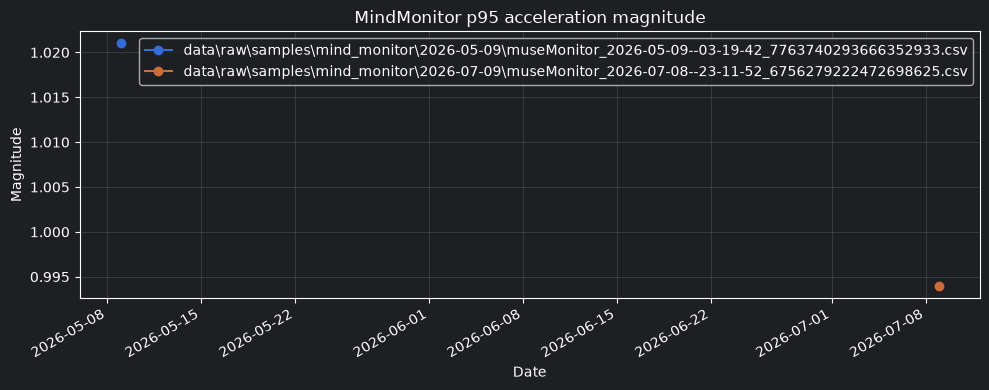

In [8]:
available_metrics = available_numeric_metrics(nightly_summary)
for metric in PLOT_METRICS:
    if metric in OPTIONAL_PLOT_METRICS and metric not in available_metrics:
        print(f"No CPAP metrics detected; skipping optional {metric} trend.")
        continue
    ylabel, title = PLOT_SPECS.get(metric, (CANONICAL_METRIC_UNITS.get(metric, "Value"), metric))
    plot_metric(nightly_summary, metric, ylabel, title)

for metric, (ylabel, title) in MINDMONITOR_TREND_SPECS.items():
    if metric in set(observations["metric"].dropna()):
        plot_observation_metric(observations, metric, ylabel, title, device=MINDMONITOR_DEVICE)
plt.show()


## Extraction Report

In [9]:
if report_path.exists():
    print(report_path.read_text(encoding="utf-8"))
else:
    print("No extraction report found yet.")

# SleepPy Extraction Report

This report summarizes automated first-pass extraction from screenshots, PDFs, and CSV sensor logs.

This is exploratory wellness data analysis only. It is not medical diagnosis, treatment advice, or a replacement for clinician review.

- Night/device rows: 42
- Extracted values: 420

## Values By Device

- Muse S MindMonitor: 58
- Oura Ring 3 toe: 134
- Oura Ring 4 finger: 133
- ResMed AirSense 11: 6
- Samsung Watch: 1
- Samsung Watch / SleepWatch: 88

## Canonical Metrics Available

- total_sleep_minutes
- time_in_bed_minutes
- sleep_efficiency_pct
- sleep_score
- avg_hr_bpm
- min_hr_bpm
- avg_hrv_ms
- avg_spo2_pct
- respiratory_rate_bpm
- cpap_ahi
- cpap_usage_hours
- cpap_leak_rate
- awake_minutes
- rem_minutes
- light_minutes
- deep_minutes
- breathing_label

## Confidence By Device

- Muse S MindMonitor: medium = 58
- Oura Ring 3 toe: high = 134
- Oura Ring 4 finger: high = 130
- Oura Ring 4 finger: manual = 3
- ResMed AirSense 11: high = 6
- Samsung 

## TODO: Remaining structured imports

MindMonitor CSV sensor logs now have first-pass ingestion. Remaining native export importers should return the same long-form observation schema used by `device_observations_long.csv`.


In [10]:
# TODO: Add Oura CSV/JSON import for Ring 4 finger and Ring 3 toe exports.
def load_oura_export(path):
    raise NotImplementedError("Parse Oura native exports into normalized observations.")


# TODO: Add Samsung Health / SleepWatch import.
def load_samsung_sleepwatch_export(path):
    raise NotImplementedError("Parse Samsung/SleepWatch native exports into normalized observations.")


# TODO: Add Muse screenshot/PDF table or native export import beyond MindMonitor sensor CSVs.
def load_muse_export(path):
    raise NotImplementedError("Parse Muse exports into normalized observations.")


# TODO: Add OSCAR and SleepScope structured export import.
def load_cpap_export(path):
    raise NotImplementedError("Parse OSCAR/SleepScope exports into normalized observations.")
